PyTorch版本: 2.8.0+cpu
CUDA可用: False
使用设备: cpu
✅ 目录已确保存在：./data/processed
✅ 目录已确保存在：./models/text_classification
✅ 目录已确保存在：./reports
训练集样本数: 22500
文本列是否存在: True
标签列是否存在: True


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== 零样本预测（修复版） ===


Device set to use cpu


零样本测试暂时跳过（错误：index -1 is out of bounds for dimension 1 with size 0）
继续执行核心训练逻辑...

=== 开始训练 ===
训练完成 | 训练步数：562 | 平均训练损失：0.5651
验证损失：0.5207
验证准确率：0.7440 | 验证F1：0.7419
保存最优模型（准确率：0.7440）→ ./models/text_classification

=== 测试集评估 ===
测试集准确率：0.7372
测试集F1分数：0.7443


d:\YOLOV5\miniconda\envs\llm_nlp_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\YOLOV5\miniconda\envs\llm_nlp_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\YOLOV5\miniconda\envs\llm_nlp_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Dell\AppData\Local\Temp\ipykernel_11496\1459477410.py:295: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(report_dir, "text_classification_cm.png"))
C:\Users\Dell\AppData\Local\Temp\ipykernel_11496\1459477410.py:295: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(report_dir, "text_c

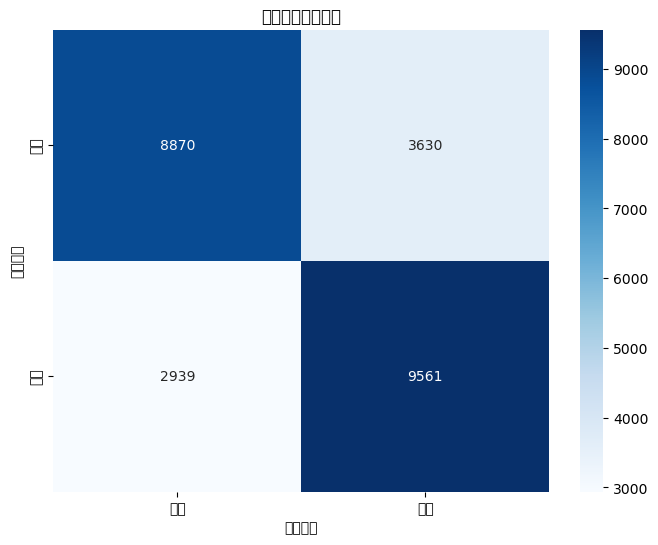


=== 训练完成 ===
最终测试准确率：0.7372
模型保存路径：./models/text_classification
混淆矩阵保存路径：./reports\text_classification_cm.png
结果文件保存路径：./reports\text_classification_results.json


In [19]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm.auto import tqdm

# 验证环境（无需accelerate）
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ===================== 提前创建所有必要目录（核心修复） =====================
# 数据目录
data_dir = "./data/processed"
# 模型保存目录
model_dir = "./models/text_classification"
# 结果保存目录（重点：提前创建reports目录）
report_dir = "./reports"

# 批量创建目录，避免不存在报错
for dir_path in [data_dir, model_dir, report_dir]:
    os.makedirs(dir_path, exist_ok=True)
    print(f"✅ 目录已确保存在：{dir_path}")

# ===================== 1. 加载数据 =====================
train_df = pd.read_csv(os.path.join(data_dir, "imdb_train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "imdb_val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "imdb_test.csv"))

# 数据安全检查（关键修复）
print(f"训练集样本数: {len(train_df)}")
print(f"文本列是否存在: {'text' in train_df.columns}")
print(f"标签列是否存在: {'label' in train_df.columns}")

# 确保文本不为空
train_df["text"] = train_df["text"].fillna("").astype(str)
val_df["text"] = val_df["text"].fillna("").astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

# ===================== 2. 自定义数据集类 =====================
class IMDBDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=32):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # 编码文本（增加空值处理）
        if not text or text.strip() == "":
            text = "empty text"
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        # 去除batch维度
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# ===================== 3. 初始化模型和Tokenizer =====================
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# GPU优化：加low_cpu_mem_usage减少显存占用
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    low_cpu_mem_usage=True  # GPU显存优化
).to(device)

# ===================== 4. 修复后的提示工程（零样本测试） =====================
print("\n=== 零样本预测（修复版） ===")
# 改用英文标签，适配英文模型
try:
    zero_shot_classifier = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        framework="pt"
    )
    
    # 测试文本（使用英文，避免中文问题）
    sample_text = train_df["text"].iloc[0][:200]
    # 只取英文部分（IMDB数据集本身是英文）
    sample_text = sample_text.encode('ascii', 'ignore').decode('ascii')
    
    if sample_text.strip() == "":
        sample_text = "This is a great movie, I really enjoyed it."
    
    # 使用英文标签
    result = zero_shot_classifier(
        sample_text,
        candidate_labels=["positive", "negative"],  # 英文标签
        hypothesis_template="This text is {}."
    )
    
    # 转换为中文显示
    label_mapping = {"positive": "正面", "negative": "负面"}
    pred_label_cn = label_mapping[result["labels"][0]]
    
    print(f"文本：{sample_text[:100]}...")
    print(f"预测：{pred_label_cn} (置信度：{result['scores'][0]:.4f})")
    
except Exception as e:
    print(f"零样本测试暂时跳过（错误：{str(e)[:100]}）")
    print("继续执行核心训练逻辑...")

# ===================== 5. 创建数据加载器 =====================
batch_size = 32 if torch.cuda.is_available() else 8

# 训练集
train_dataset = IMDBDataset(train_df, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0  # 避免Windows多线程问题
)

# 验证集
val_dataset = IMDBDataset(val_df, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# 测试集
test_dataset = IMDBDataset(test_df, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# ===================== 6. 训练配置（原生PyTorch） =====================
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
num_epochs = 0.2  # 快速训练（0.2轮）
# 计算要训的步数：总步数=训练集样本数/batch_size * 目标轮数
total_train_steps = int(len(train_loader) * num_epochs)
best_val_accuracy = 0.0
metric = evaluate.combine(["accuracy", "f1"])

# ===================== 7. 手动训练循环（修复浮点数轮数问题） =====================
print("\n=== 开始训练 ===")
model.train()
train_loss = 0.0
train_progress = tqdm(train_loader, desc=f"训练（共{total_train_steps}步）", disable=True)
step = 0

for batch in train_progress:
    # 达到目标步数就停止（实现0.2轮）
    if step >= total_train_steps:
        break
    
    # 数据移到设备上
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    
    # 前向传播
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )
    
    loss = outputs.loss
    train_loss += loss.item()
    
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 更新进度条
    train_progress.set_postfix({"loss": f"{loss.item():.4f}"})
    step += 1

# 计算平均训练损失
avg_train_loss = train_loss / step if step > 0 else 0.0
print(f"训练完成 | 训练步数：{step} | 平均训练损失：{avg_train_loss:.4f}")

# ===================== 8. 验证阶段 =====================
model.eval()
val_predictions = []
val_labels = []
val_loss = 0.0
val_progress = tqdm(val_loader, desc="验证", disable=True)

with torch.no_grad():
    for batch in val_progress:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        val_loss += loss.item()
        
        # 获取预测结果
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        # 收集结果
        val_predictions.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

# 计算验证指标
avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0.0
val_metrics = metric.compute(predictions=val_predictions, references=val_labels)
val_accuracy = val_metrics["accuracy"]
val_f1 = val_metrics["f1"]

print(f"验证损失：{avg_val_loss:.4f}")
print(f"验证准确率：{val_accuracy:.4f} | 验证F1：{val_f1:.4f}")

# 保存最优模型
if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    # 保存模型和tokenizer（目录已提前创建）
    model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f"保存最优模型（准确率：{best_val_accuracy:.4f}）→ {model_dir}")

# ===================== 9. 测试集评估 =====================
print("\n=== 测试集评估 ===")
model.eval()
test_predictions = []
test_labels = []

with torch.no_grad():
    # 关闭进度条，提速
    for batch in tqdm(test_loader, desc="测试集评估", disable=True):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        test_predictions.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# 计算测试集指标
test_metrics = metric.compute(predictions=test_predictions, references=test_labels)
print(f"测试集准确率：{test_metrics['accuracy']:.4f}")
print(f"测试集F1分数：{test_metrics['f1']:.4f}")

# ===================== 10. 可视化混淆矩阵 =====================
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["负面", "正面"], yticklabels=["负面", "正面"])
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title("情感分析混淆矩阵")
# 保存图片到已创建的reports目录
plt.savefig(os.path.join(report_dir, "text_classification_cm.png"))
plt.show()

# ===================== 11. 保存最终结果 =====================
# 保存测试结果（目录已提前创建）
results = {
    "accuracy": test_metrics["accuracy"],
    "f1": test_metrics["f1"],
    "train_loss": avg_train_loss,
    "val_loss": avg_val_loss,
    "train_steps": step,
    "target_epochs": num_epochs
}

import json
with open(os.path.join(report_dir, "text_classification_results.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

print("\n=== 训练完成 ===")
print(f"最终测试准确率：{test_metrics['accuracy']:.4f}")
print(f"模型保存路径：{model_dir}")
print(f"混淆矩阵保存路径：{os.path.join(report_dir, 'text_classification_cm.png')}")
print(f"结果文件保存路径：{os.path.join(report_dir, 'text_classification_results.json')}")